In [3]:
from simulation_functions import *

from tqdm.notebook import tqdm

In [4]:
import numpy as np
import random as rnd

from copy import deepcopy

import matplotlib.pyplot as plt

In [5]:
from simulation_functions import *
from utils_analysis_for_simulation import *

c:\Users\Utente\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Utente\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [6]:
plt.style.use("seaborn-whitegrid")
import matplotlib as mpl

mpl.rcParams.update({
    # Font
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    
    # Axes and grid
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    # Lines and markers
    "lines.linewidth": 2,
    "lines.markersize": 6,

    # Default colormap for images
    "image.cmap": "Blues",

    # Default color cycle for plots
    "axes.prop_cycle": plt.cycler(
        color=[
            "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
            "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"
        ]
    ),

    # Figure
#     "figure.figsize": (6, 4),
#     "figure.dpi": 150,

    # Legend
    "legend.frameon": False,
})

mpl.rcParams["patch.force_edgecolor"] = True

# Load data

In [1]:
import pickle

with open('../RESULTS_SIMULATION/simulation_grid_data.pkl', 'rb') as f:
    load_data = pickle.load(f)

TEST_LAMBDA=load_data['TEST_LAMBDA']
TEST_ETA=load_data['TEST_ETA']
Final_extremism_avg=load_data['Final_extremism_avg']
Final_extremism_std=load_data['Final_extremism_std']
Final_extremism_all_avg=load_data['Final_extremism_all_avg']
Final_extremism_all_std=load_data['Final_extremism_all_std']
Final_polarization_avg=load_data['Final_polarization_avg']
Final_polarization_std=load_data['Final_polarization_std']
Final_click_density=load_data['Final_click_density']
Final_extremism_stancewise_avg=load_data['Final_extremism_stancewise_avg']
Final_extremism_stancewise_std=load_data['Final_extremism_stancewise_std']
Final_stancewise_avgrank_avg=load_data['Final_stancewise_avgrank_avg']
Final_stancewise_avgrank_std=load_data['Final_stancewise_avgrank_std']

# Grid plots

In [2]:
Ea_avg=[]
Ea_std=[]

for eta, data in Final_extremism_all_avg.items():
    Ea_avg.append([])
    Ea_std.append([])
    for lmb, extremism in data.items():
        Ea_avg[-1].append(extremism)
        Ea_std[-1].append(Final_extremism_all_std[eta][lmb])

C:\Users\Utente\AppData\Local\Temp\ipykernel_12636\1516045821.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


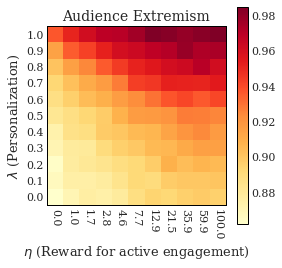

In [23]:
plt.figure(figsize=(4,4))
plt.title("Audience Extremism")
plt.imshow(Ea_avg, cmap='YlOrRd')
plt.yticks(range(len(TEST_LAMBDA)), (1-np.array(TEST_LAMBDA)).round(1))
plt.ylabel('$\lambda$ (Personalization)')
plt.xticks(range(len(TEST_ETA)), np.array(TEST_ETA).round(1), rotation=-90)
plt.xlabel('$\eta$ (Reward for active engagement)')
plt.colorbar()
plt.grid(False)
plt.savefig(f'extremism_all_grid.pdf', bbox_inches='tight')

In [15]:
P_avg=[]
P_std=[]

for eta, data in Final_polarization_avg.items():
    P_avg.append([])
    P_std.append([])
    for lmb, polarization in data.items():
        P_avg[-1].append(polarization)
        P_std[-1].append(Final_polarization_std[eta][lmb])

C:\Users\Utente\AppData\Local\Temp\ipykernel_12636\1383617093.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


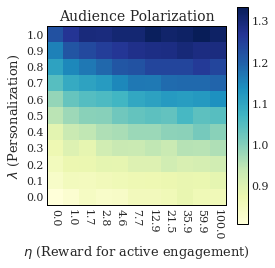

In [24]:
plt.figure(figsize=(4,4))
plt.title("Audience Polarization")
plt.imshow(P_avg, cmap='YlGnBu')
plt.yticks(range(len(TEST_LAMBDA)), (1-np.array(TEST_LAMBDA)).round(1))
plt.ylabel('$\lambda$ (Personalization)')
plt.xticks(range(len(TEST_ETA)), np.array(TEST_ETA).round(1), rotation=-90)
plt.xlabel('$\eta$ (Reward for active engagement)')
plt.colorbar()
plt.grid(False)
plt.savefig(f'polarization_grid.pdf', bbox_inches='tight')